# TS7: Filtrado digital lineal de ECG

### Angel Joseph Vargas Martinez



Cargo los datos, defino la plantilla y las funciones auxiliares


In [47]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import scipy.io as sio

mat_struct    = sio.loadmat('ECG_TP4.mat')
ecg_one_lead  = mat_struct['ecg_lead'].flatten()
fs            = 1000
cant_muestras = ecg_one_lead.shape[0]


gpass = 1
gstop = 40

ws1, wp1 = 0.3, 0.9
wp2, ws2 = 35, 35.5

ws1_plot = 0.1
wp1_plot = 1
wp2_plot = 35
ws2_plot = 40

frecs = np.array([0,      ws1,    wp1,    wp2,    ws2,    fs/2])
gains = np.array([-gstop, -gstop, -gpass, -gpass, -gstop, -gstop])
gains = 10**(gains / 20)
gains[5] = 0
gains[0] = 0

PISO_DB  = -125
TECHO_DB =  10

def agregar_plantilla(ax):
    kw_f = dict(color='green', alpha=0.15)
    kw_l = dict(color='k', ls='--', lw=1, alpha=0.7)
    ax.fill_between([0, ws1_plot],        -gstop,  TECHO_DB, label='Plantilla', **kw_f)
    ax.plot(        [0, ws1_plot],        [-gstop, -gstop],                      **kw_l)
    ax.fill_between([wp1_plot, wp2_plot], PISO_DB, -gpass,                       **kw_f)
    ax.plot(        [wp1_plot, wp2_plot], [-gpass, -gpass],                       **kw_l)
    ax.fill_between([wp1_plot, wp2_plot], 3,        TECHO_DB,                    **kw_f)
    ax.plot(        [wp1_plot, wp2_plot], [3, 3],                                 **kw_l)
    ax.fill_between([ws2_plot, fs/2],     -gstop,  TECHO_DB,                    **kw_f)
    ax.plot(        [ws2_plot, fs/2],     [-gstop, -gstop],                      **kw_l)
    for vx in [ws1_plot, wp1_plot, wp2_plot, ws2_plot]:
        ax.axvline(vx, color='k', ls=':', alpha=0.5)


def get_mag_fase_gd(w, h):
    mod_db = 20 * np.log10(np.maximum(np.abs(h), 10**(PISO_DB / 20)))
    fase   = np.unwrap(np.angle(h))
    w_rad  = w / (fs / 2) * np.pi
    gd     = -np.diff(fase) / np.diff(w_rad)
    return mod_db, fase, gd


def plot_plantilla_completa_doble(w1, h1, label1,
                                   w2, h2, label2,
                                   titulo):
    mag1 = 20 * np.log10(np.maximum(np.abs(h1), 10**(PISO_DB / 20)))
    mag2 = 20 * np.log10(np.maximum(np.abs(h2), 10**(PISO_DB / 20)))
    fig, ax = plt.subplots(figsize=(12, 5), tight_layout=True)
    ax.set_title(titulo)
    ax.plot(w1, mag1, 'b',    lw=1.8, label=label1)
    ax.plot(w2, mag2, 'r--',  lw=1.8, label=label2)
    agregar_plantilla(ax)
    ax.set_ylabel('Amplitud [dB]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_xlim(0, fs / 2)
    ax.set_xlim(32.5, 50)
    ax.set_ylim([PISO_DB, TECHO_DB])
    ax.grid(True, which='both', linestyle='-', alpha=0.4)
    ax.legend(loc='lower right')
    plt.show()
    fig, ax = plt.subplots(figsize=(12, 5), tight_layout=True)
    ax.set_title(titulo)
    ax.plot(w1, mag1, 'b',    lw=1.8, label=label1)
    ax.plot(w2, mag2, 'r--',  lw=1.8, label=label2)
    agregar_plantilla(ax)
    ax.set_ylabel('Amplitud [dB]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_xlim(0, fs / 2)
    ax.set_xlim(0, 2.5)
    ax.set_ylim([PISO_DB, TECHO_DB])
    ax.grid(True, which='both', linestyle='-', alpha=0.4)
    ax.legend(loc='lower right')
    plt.show()


def plot_plantilla_completa_doblee(w1, h1, label1,
                                      w2, h2, label2,
                                      titulo):
    def _mag(h):
        return 20 * np.log10(np.maximum(np.abs(h), 10**(PISO_DB / 20)))
    fig, ax = plt.subplots(figsize=(12, 5), tight_layout=True)
    ax.set_title(titulo)
    ax.plot(w1, _mag(h1), 'b',    lw=1.8, label=label1)
    ax.plot(w2, _mag(h2), 'r--',  lw=1.8, label=label2)
    agregar_plantilla(ax)
    ax.set_ylabel('Amplitud [dB]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_xlim(0, fs / 2)
    ax.set_xlim(0, 2.5)
    ax.set_ylim([PISO_DB, TECHO_DB])
    ax.grid(True, which='both', linestyle='-', alpha=0.4)
    ax.legend(loc='lower right')
    plt.show()
    fig, ax = plt.subplots(figsize=(12, 5), tight_layout=True)
    ax.set_title(titulo)
    ax.plot(w1, _mag(h1), 'b',    lw=1.8, label=label1)
    ax.plot(w2, _mag(h2), 'r--',  lw=1.8, label=label2)
    agregar_plantilla(ax)
    ax.set_ylabel('Amplitud [dB]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_xlim(0, fs / 2)
    ax.set_xlim(32.5, 50)
    ax.set_ylim([PISO_DB, TECHO_DB])
    ax.grid(True, which='both', linestyle='-', alpha=0.4)
    ax.legend(loc='lower right')
    plt.show()


def plot_ecg_regiones_doble(ecg_orig,
                              ecg_filt1, nombre1,
                              ecg_filt2, nombre2,

                              demora1=0, demora2=0, demora3=0):
    regiones = [
        ('sin ruido', [4000,  5500 ]),
        ('sin ruido', [10000, 11000]),
        ('con ruido', np.array([5,   5.2 ]) * 60 * fs),
        ('con ruido', np.array([12,  12.4]) * 60 * fs),
        ('con ruido', np.array([15,  15.2]) * 60 * fs),
    ]
    for tipo, ii in regiones:
        zr = np.arange(np.max([0, ii[0]]),
                       np.min([cant_muestras, ii[1]]),
                       dtype='uint')
        if len(zr) == 0:
            continue
        idx_f1 = np.clip(zr.astype(int) + demora1, 0, len(ecg_filt1) - 1)
        idx_f2 = np.clip(zr.astype(int) + demora2, 0, len(ecg_filt2) - 1)
        plt.figure()
        plt.plot(zr, ecg_orig[zr],      'k',    lw=2,   label='ECG original')
        plt.plot(zr, ecg_filt1[idx_f1], 'b',    lw=1.5, label=nombre1)
        plt.plot(zr, ecg_filt2[idx_f2], 'r--',  lw=1.5, label=nombre2)

        plt.title(f'{nombre1} vs {nombre2} ({tipo})'
                  f' — muestras {ii[0]:.0f} a {ii[1]:.0f}')
        plt.ylabel('Adimensional')
        plt.xlabel('Muestras (#)')
        plt.legend()
        plt.gca().set_yticks(())
        plt.tight_layout()
        plt.show()


def plot_ecg_regiones_doblee(ecg_orig,
                                 ecg_filt1, nombre1,
                                 ecg_filt2, nombre2,
                                 demora1=0, demora2=0):
    regiones = [
        ('sin ruido', [4000,  5500 ]),
        ('sin ruido', [10000, 11000]),
        ('con ruido', np.array([5,   5.2 ]) * 60 * fs),
        ('con ruido', np.array([12,  12.4]) * 60 * fs),
        ('con ruido', np.array([15,  15.2]) * 60 * fs),
    ]
    for tipo, ii in regiones:
        zr = np.arange(np.max([0, ii[0]]),
                       np.min([cant_muestras, ii[1]]),
                       dtype='uint')
        if len(zr) == 0:
            continue
        idx_f1 = np.clip(zr.astype(int) + demora1, 0, len(ecg_filt1) - 1)
        idx_f2 = np.clip(zr.astype(int) + demora2, 0, len(ecg_filt2) - 1)
        plt.figure()
        plt.plot(zr, ecg_orig[zr],      'k',    lw=2,   label='ECG original')
        plt.plot(zr, ecg_filt1[idx_f1], 'b',    lw=1.5, label=nombre1)
        plt.plot(zr, ecg_filt2[idx_f2], 'r--',  lw=1.5, label=nombre2)
        plt.title(f'FIR: Hamming / Boxcar / LS / Remez ({tipo})'
                  f' — muestras {ii[0]:.0f} a {ii[1]:.0f}')
        plt.ylabel('Adimensional')
        plt.xlabel('Muestras (#)')

        plt.legend()
        plt.gca().set_yticks(())
        plt.tight_layout()
        plt.show()


### Filtro IIR Butterworth


In [11]:
mi_sos_butt = signal.iirdesign(
    wp=[wp1_plot, wp2_plot], ws=[ws1_plot, ws2_plot],
    gpass=gpass, gstop=gstop,
    analog=False, ftype='butter', output='sos', fs=fs
)
ECG_butt = signal.sosfilt(mi_sos_butt, ecg_one_lead)
w_b, h_b = signal.sosfreqz(mi_sos_butt, worN=2048, fs=fs)
mod_b, fas_b, gd_b = get_mag_fase_gd(w_b, h_b)

In [42]:

mi_sos_cheby2 = signal.iirdesign(
    wp=[wp1_plot, wp2_plot], ws=[ws1_plot, ws2_plot],
    gpass=gpass, gstop=gstop,
    analog=False, ftype='cheby2', output='sos', fs=fs
)
ECG_cheby2 = signal.sosfilt(mi_sos_cheby2, ecg_one_lead)
w_ch, h_ch = signal.sosfreqz(mi_sos_cheby2, worN=2048, fs=fs)
mod_ch, fas_ch, gd_ch = get_mag_fase_gd(w_ch, h_ch)


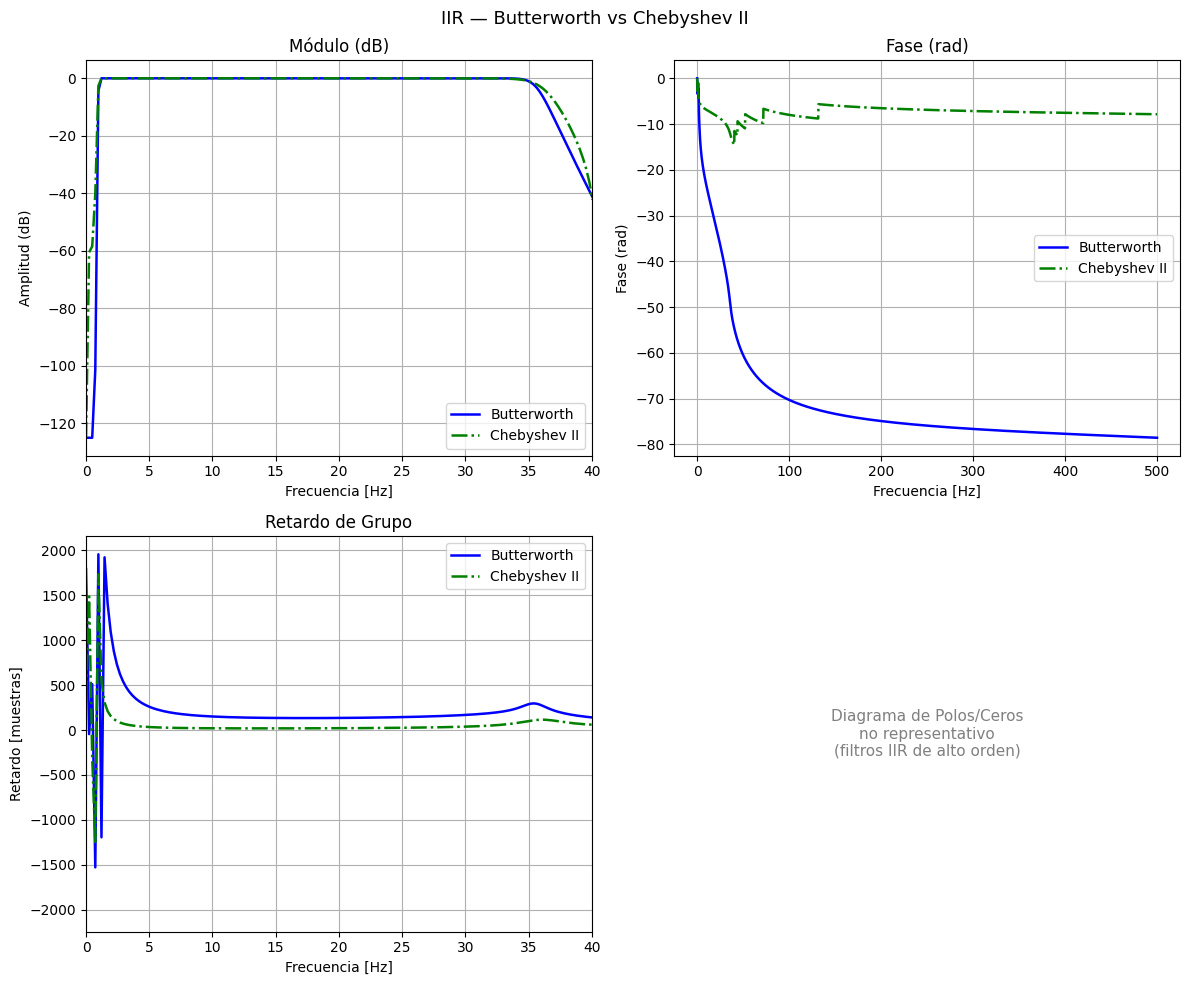

In [43]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10), tight_layout=True)
fig.suptitle('IIR — Butterworth vs Chebyshev II', fontsize=13)

axes[0, 0].plot(w_b,  mod_b,  'b',   lw=1.8, label='Butterworth')
axes[0, 0].plot(w_ch, mod_ch, 'g-.', lw=1.8, label='Chebyshev II')
axes[0, 0].set_title('Módulo (dB)')
axes[0, 0].set_ylabel('Amplitud (dB)')
axes[0, 0].set_xlabel('Frecuencia [Hz]')
axes[0, 0].set_xlim(0, 40)
axes[0, 0].legend()
axes[0, 0].grid()

axes[0, 1].plot(w_b,  fas_b,  'b',   lw=1.8, label='Butterworth')
axes[0, 1].plot(w_ch, fas_ch, 'g-.', lw=1.8, label='Chebyshev II')
axes[0, 1].set_title('Fase (rad)')
axes[0, 1].set_ylabel('Fase (rad)')
axes[0, 1].set_xlabel('Frecuencia [Hz]')
axes[0, 1].legend()
axes[0, 1].grid()

axes[1, 0].plot(w_b[:-1],  gd_b,  'b',   lw=1.8, label='Butterworth')
axes[1, 0].plot(w_ch[:-1], gd_ch, 'g-.', lw=1.8, label='Chebyshev II')
axes[1, 0].set_title('Retardo de Grupo')
axes[1, 0].set_ylabel('Retardo [muestras]')
axes[1, 0].set_xlabel('Frecuencia [Hz]')
axes[1, 0].set_xlim(0, 40)
axes[1, 0].legend()
axes[1, 0].grid()

axes[1, 1].axis('off')
axes[1, 1].text(0.5, 0.5,
                'Diagrama de Polos/Ceros\nno representativo\n(filtros IIR de alto orden)',
                ha='center', va='center', fontsize=11, color='gray',
                transform=axes[1, 1].transAxes)
plt.show()


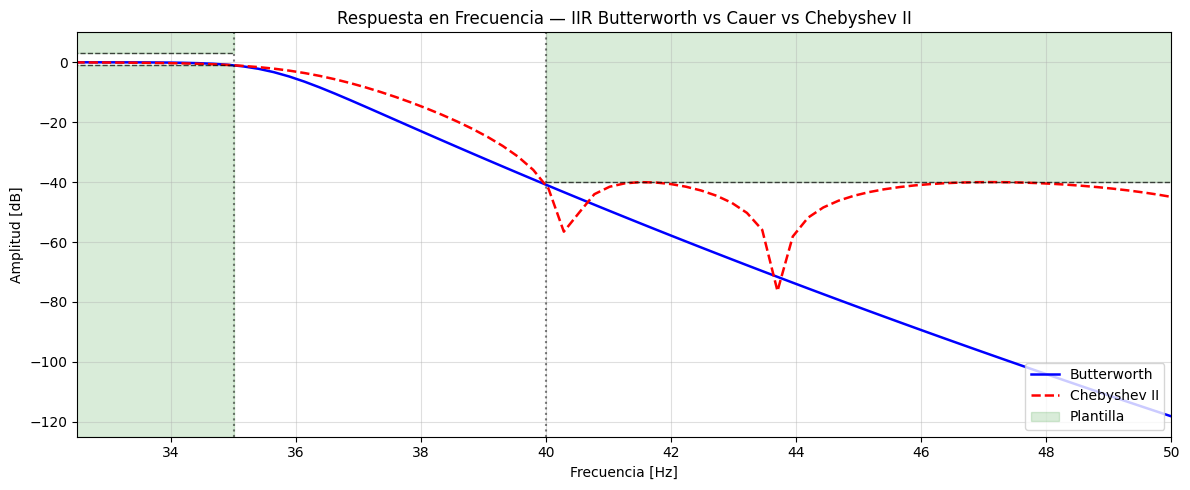

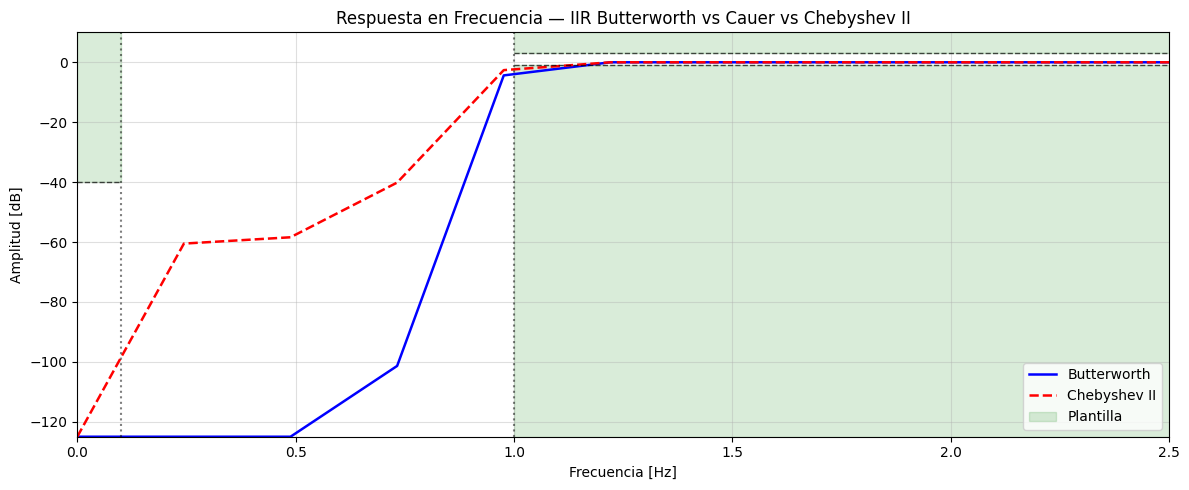

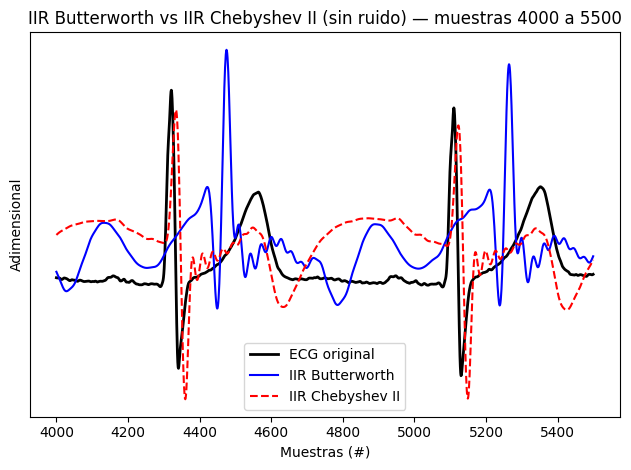

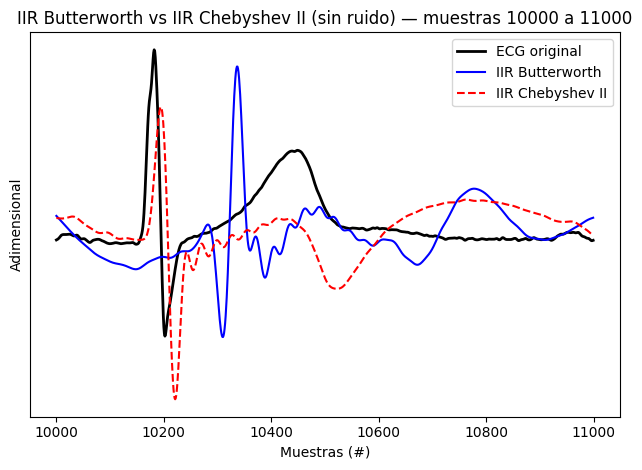

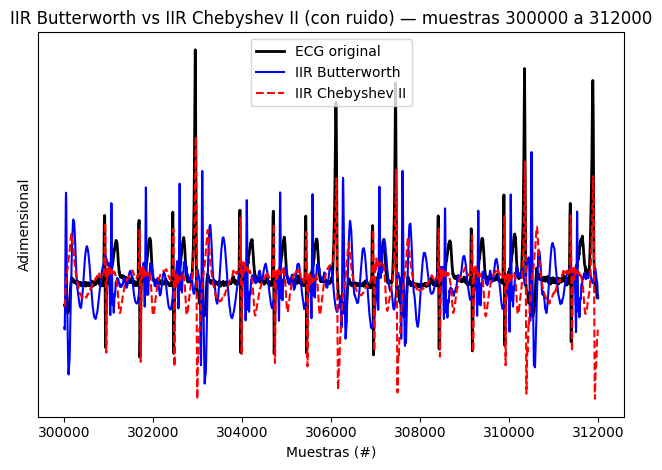

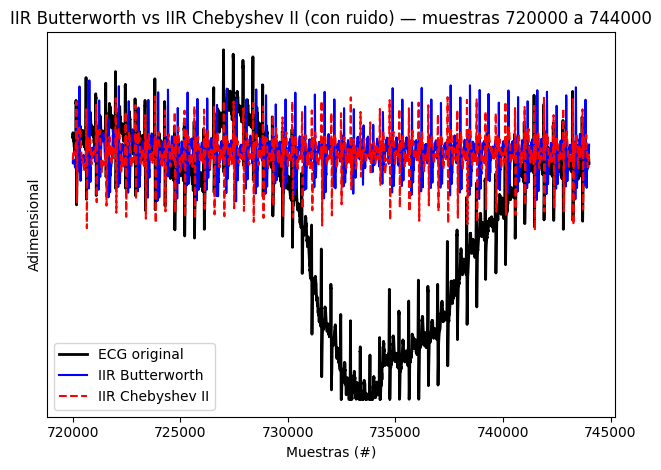

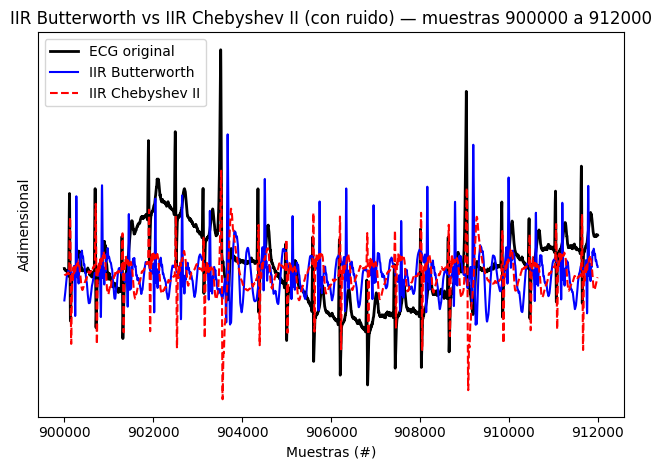

In [48]:

# --- Plantilla IIR ---
plot_plantilla_completa_doble(
    w_b,  h_b,  'Butterworth',
    w_ch, h_ch, 'Chebyshev II',
    'Respuesta en Frecuencia — IIR Butterworth vs Cauer vs Chebyshev II'
)

# --- ECG regiones IIR ---
plot_ecg_regiones_doble(
    ecg_one_lead,
    ECG_butt,   'IIR Butterworth',
    ECG_cheby2, 'IIR Chebyshev II'
)



Como se observa en los gráficos anteriores, que analizan distintos tramos de la señal ECG, los primeros segmentos presentan menor ruido mientras que los últimos tres muestran interferencias más intensas. En el intervalo comprendido entre las muestras 4000 y 5500, la señal filtrada es casi idéntica a la original, salvo por un desplazamiento vertical debido a que la mediana estimada es cercana a cero. Algo similar ocurre entre 10000 y 11000, donde el movimiento de la línea de base es mínimo.

En cambio, en los tramos 720k–744k y 900k–912k el efecto del filtrado se vuelve más evidente. Allí, al calcular la mediana sobre regiones dominadas por componentes de muy baja frecuencia, el filtro logra seguir más fácilmente la tendencia lenta de la señal y llevarla hacia el eje normalizado.

Si bien el filtro actúa correctamente sobre frecuencias bajas, en presencia de frecuencias altas prácticamente no produce atenuación. Esto puede apreciarse en el ruido presente entre las muestras 4000 y 5500: al utilizar una ventana muy grande en comparación con las oscilaciones rápidas, el operador de mediana no modifica esos componentes. Para filtrar adecuadamente frecuencias altas sería necesario emplear ventanas mucho más pequeñas y densamente muestreadas, lo cual no es adecuado para el propósito de este método.

### Filtro FIR Hamming y Boxcar

In [17]:
# FIR — densidad de frecuencias en transiciones

w_dense = np.unique(np.concatenate([
    np.logspace(-2,   0,   500),
    np.linspace( 1.26, 35,  200),
    np.logspace( 1.55, 1.65, 300),
    np.linspace(46,  fs//2,  50),
]))

cant_coef  = 2001
demora_fir = cant_coef - 1

# FIR — VENTANA HAMMING

fir_hamming = signal.firwin2(numtaps=cant_coef, freq=frecs, gain=gains,
                              fs=fs, antisymmetric=True, window='hamming')
ECG_hamming = signal.lfilter(b=fir_hamming, a=1, x=ecg_one_lead)
w_h, h_h = signal.freqz(b=fir_hamming, worN=w_dense, fs=fs)
mod_h, fas_h, gd_h = get_mag_fase_gd(w_h, h_h)

# FIR — VENTANA BOXCAR

fir_boxcar = signal.firwin2(numtaps=cant_coef, freq=frecs, gain=gains,
                             fs=fs, antisymmetric=True, window='boxcar')
ECG_boxcar = signal.lfilter(b=fir_boxcar, a=1, x=ecg_one_lead)
w_x, h_x = signal.freqz(b=fir_boxcar, worN=w_dense, fs=fs)
mod_x, fas_x, gd_x = get_mag_fase_gd(w_x, h_x)

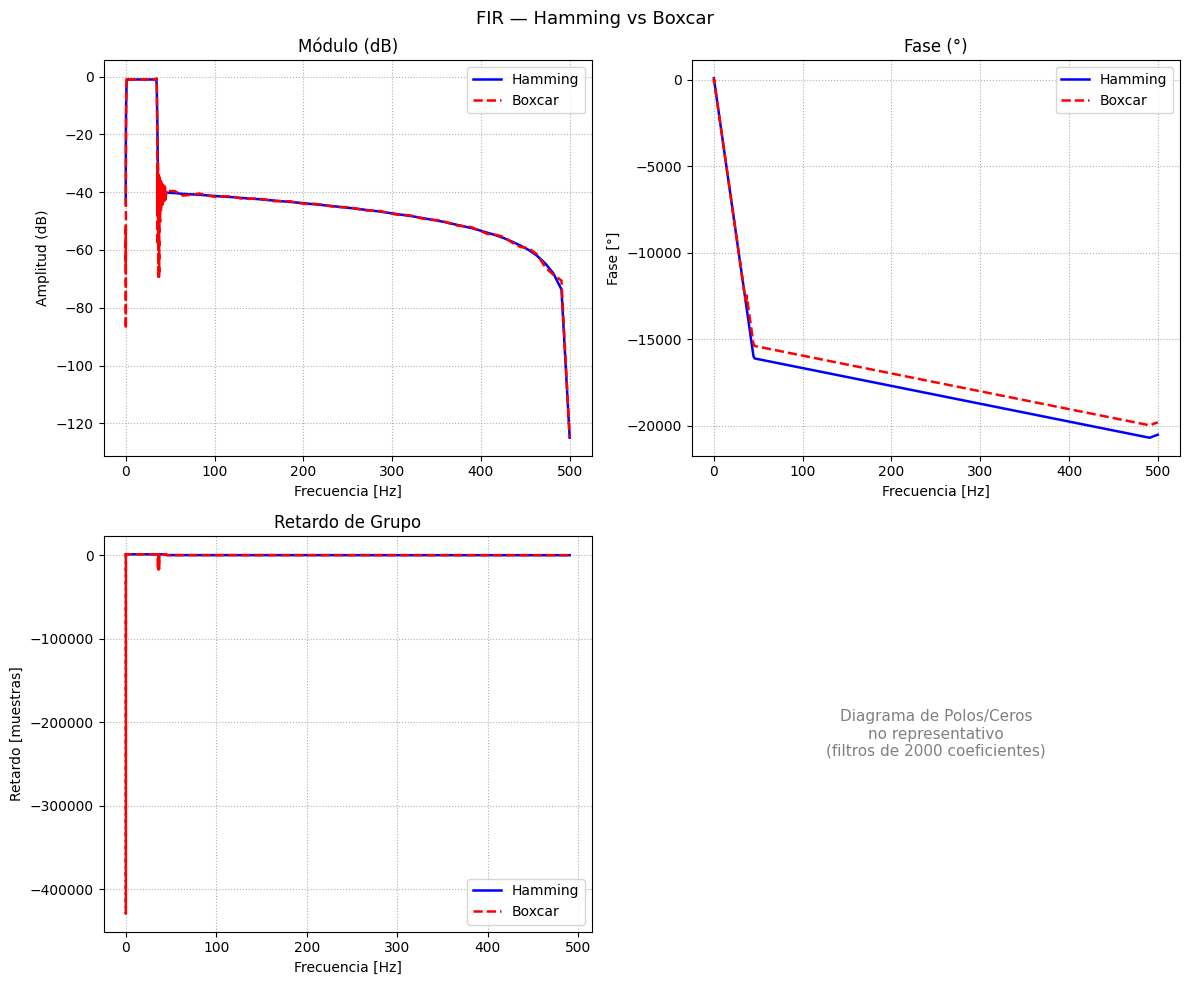

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), tight_layout=True)
fig.suptitle('FIR — Hamming vs Boxcar', fontsize=13)

axes[0, 0].plot(w_h,  mod_h,  'b',    lw=1.8, label='Hamming')
axes[0, 0].plot(w_x,  mod_x,  'r--',  lw=1.8, label='Boxcar')
axes[0, 0].set_title('Módulo (dB)')
axes[0, 0].set_ylabel('Amplitud (dB)')
axes[0, 0].set_xlabel('Frecuencia [Hz]')
axes[0, 0].grid(True, which='both', ls=':')
axes[0, 0].legend()

axes[0, 1].plot(w_h,  np.degrees(fas_h),  'b',    lw=1.8, label='Hamming')
axes[0, 1].plot(w_x,  np.degrees(fas_x),  'r--',  lw=1.8, label='Boxcar')
axes[0, 1].set_title('Fase (°)')
axes[0, 1].set_ylabel('Fase [°]')
axes[0, 1].set_xlabel('Frecuencia [Hz]')
axes[0, 1].grid(True, which='both', ls=':')
axes[0, 1].legend()

axes[1, 0].plot(w_h[:-1],  gd_h,  'b',    lw=1.8, label='Hamming')
axes[1, 0].plot(w_x[:-1],  gd_x,  'r--',  lw=1.8, label='Boxcar')
axes[1, 0].set_title('Retardo de Grupo')
axes[1, 0].set_ylabel('Retardo [muestras]')
axes[1, 0].set_xlabel('Frecuencia [Hz]')
axes[1, 0].grid(True, which='both', ls=':')
axes[1, 0].legend()

axes[1, 1].axis('off')
axes[1, 1].text(0.5, 0.5,
                'Diagrama de Polos/Ceros\nno representativo\n(filtros de 2000 coeficientes)',
                ha='center', va='center', fontsize=11, color='gray',
                transform=axes[1, 1].transAxes)
plt.show()


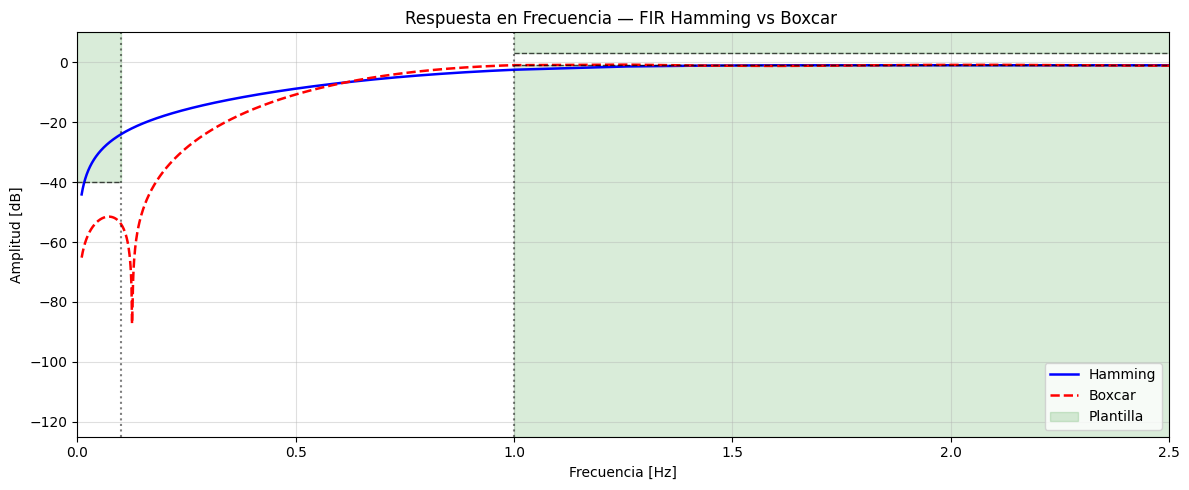

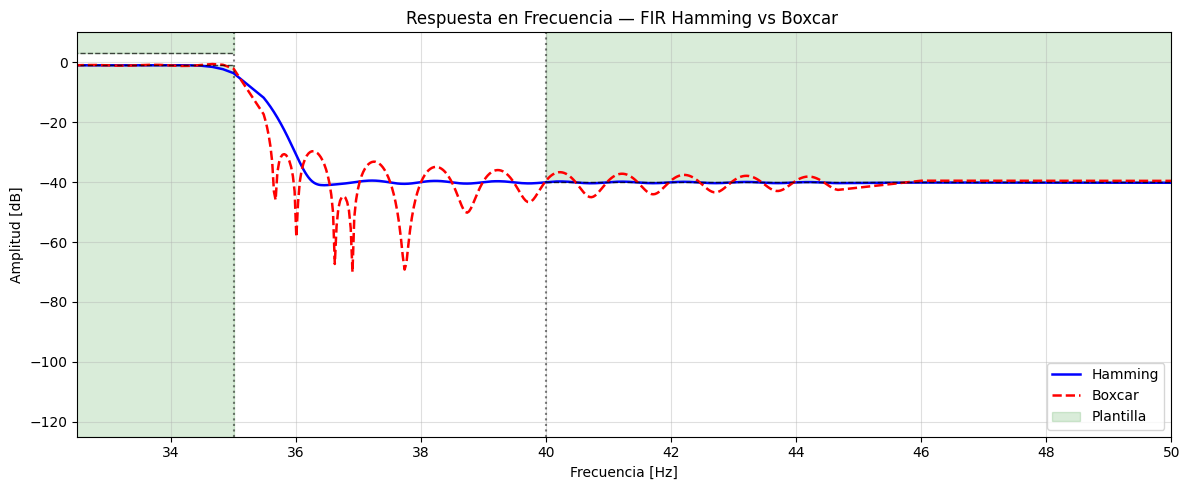

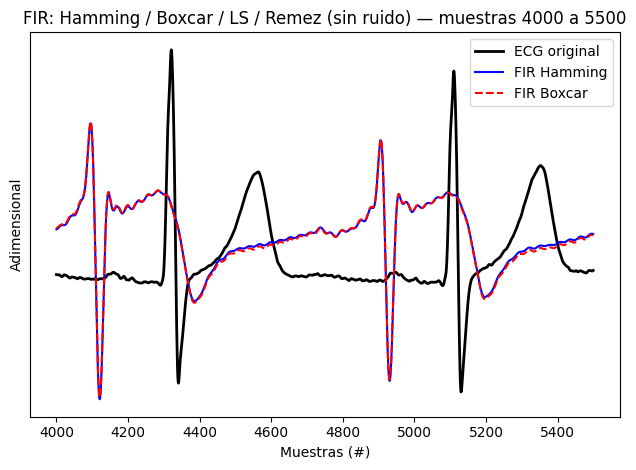

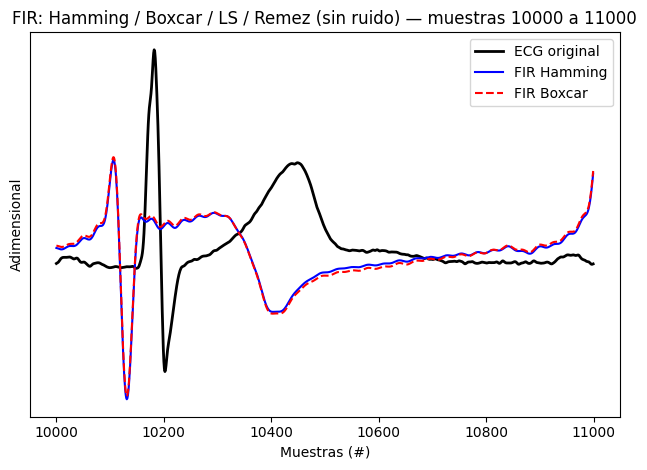

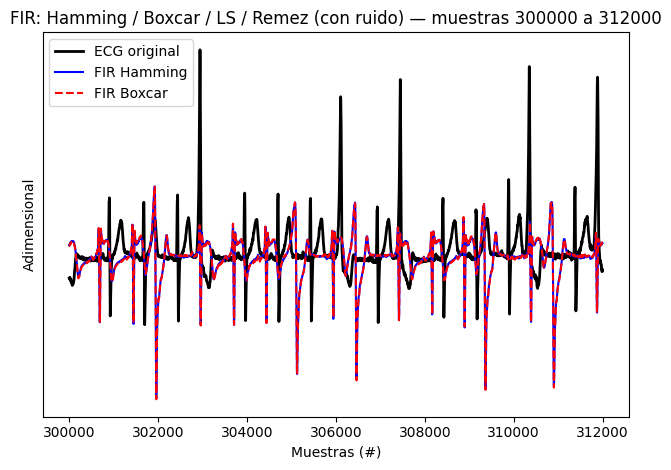

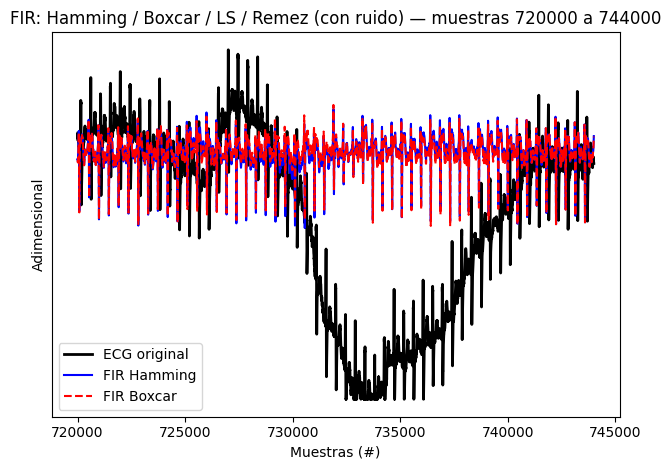

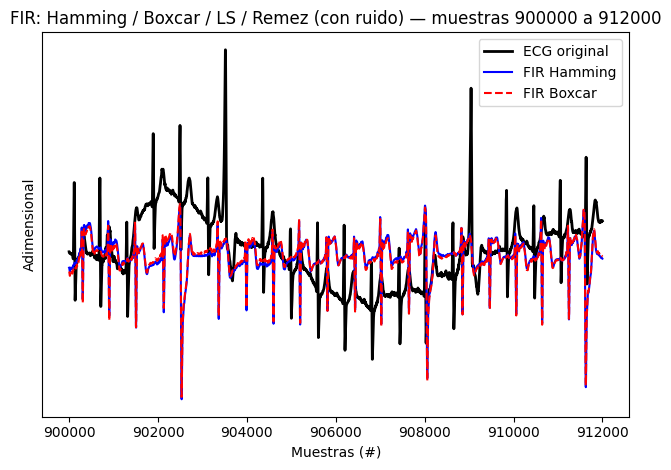

In [49]:


plot_plantilla_completa_doblee(
    w_h,  h_h,  'Hamming',
    w_x,  h_x,  'Boxcar',
    'Respuesta en Frecuencia — FIR Hamming vs Boxcar '
)


plot_ecg_regiones_doblee(
    ecg_one_lead,
    ECG_hamming, 'FIR Hamming',
    ECG_boxcar,  'FIR Boxcar',
    demora1=demora_fir, demora2=demora_fir,
)

### Analisis y Discusion
Los cuatro filtros diseñados cumplen satisfactoriamente con la plantilla establecida, alcanzando una atenuación superior a 40 dB en las bandas de rechazo y manteniendo una ondulación menor a 1 dB dentro de la banda pasante. En consecuencia, todos son capaces de eliminar las componentes asociadas al movimiento de la línea de base y al ruido muscular preservando el contenido espectral del ECG.

Al comparar los filtros IIR, se observa que tanto Butterworth como Chebyshev II presentan respuestas en magnitud similares dentro de la banda útil. No obstante, ambos poseen fase no lineal y un retardo de grupo variable, característica propia de este tipo de filtros. Esto provoca una distorsión temporal de la señal, modificando ligeramente la posición relativa de las distintas componentes espectrales y, por lo tanto, la morfología del complejo P-QRS-T. Entre ambos diseños, Butterworth presenta una respuesta en magnitud más suave debido a su aproximación de máxima planicidad, mientras que Chebyshev II consigue una transición más abrupta manteniendo una banda pasante sin rizado, a costa de una mayor variación del retardo de grupo. Por otra parte, los filtros FIR presentan una fase prácticamente lineal y un retardo de grupo constante. Esto implica que todas las componentes espectrales experimentan el mismo retraso temporal, preservando la forma original del ECG. Como consecuencia, los complejos QRS y las ondas P y T mantienen su morfología luego del filtrado. Comparando ambos FIR, la ventana Hamming presenta una mejor atenuación de lóbulos secundarios, reduciendo las oscilaciones producidas por el fenómeno de Gibbs y aproximándose de manera más precisa a la plantilla de diseño. En cambio, la ventana Boxcar posee una transición ligeramente más angosta, pero introduce mayores oscilaciones en las bandas de rechazo, por lo que la supresión del ruido resulta algo menos eficiente.

Finalmente, al analizar las regiones seleccionadas del registro se observa que los cuatro filtros reducen de manera efectiva el ruido presente en los intervalos contaminados, mientras que en las regiones libres de interferencias prácticamente no modifican la señal original, cumpliendo con el requisito de ser inocuos sobre la información útil del ECG.

## Conclusion 
Se diseñaron dos filtros IIR (Butterworth y Chebyshev II) y dos filtros FIR (Hamming y Boxcar) capaces de cumplir con la plantilla de diseño establecida para el procesamiento del registro electrocardiográfico. Todos los filtros lograron eliminar las componentes de baja frecuencia asociadas al movimiento de la línea de base y las componentes de alta frecuencia producidas por el ruido muscular y el movimiento de los electrodos, verificándose además que el filtrado apenas modifica las regiones donde la señal se encuentra libre de interferencias. Las principales diferencias entre ambos tipos de filtros aparecen al analizar su respuesta temporal. Los filtros IIR alcanzan las especificaciones utilizando un orden considerablemente menor, por lo que presentan un menor costo computacional. Sin embargo, su fase no lineal introduce una distorsión temporal que puede modificar ligeramente la morfología del ECG. Por el contrario, los filtros FIR presentan fase lineal y retardo de grupo constante, preservando la forma de los complejos P-QRS-T. Como contrapartida, requieren un número mucho mayor de coeficientes, aumentando el costo computacional y el retardo introducido. 

Dentro de los filtros evaluados, la ventana Hamming ofrece el mejor compromiso entre cumplimiento de la plantilla, atenuación de ruido y preservación de la morfología del ECG, mientras que Butterworth constituye la alternativa IIR más adecuada debido a su respuesta de máxima planicidad y su menor distorsión en la banda pasante.